In [1]:
import pandas as pd
import numpy as np
import re
import os
import pickle

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import nltk
from nltk.corpus import stopwords

In [2]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
fake_path = "../data/Fake.csv"
true_path = "../data/True.csv"

fake_df = pd.read_csv(fake_path)
true_df = pd.read_csv(true_path)

print("Fake News Shape:", fake_df.shape)
print("True News Shape:", true_df.shape)

Fake News Shape: (23481, 4)
True News Shape: (21417, 4)


In [4]:
print("Fake News Columns:")
print(fake_df.columns.tolist())

print("\nTrue News Columns:")
print(true_df.columns.tolist())

Fake News Columns:
['title', 'text', 'subject', 'date']

True News Columns:
['title', 'text', 'subject', 'date']


In [5]:
fake_df["label"] = "Fake"
true_df["label"] = "True"

print(fake_df["label"].value_counts())
print(true_df["label"].value_counts())

label
Fake    23481
Name: count, dtype: int64
label
True    21417
Name: count, dtype: int64


In [6]:
print("Fake News Columns:")
print(fake_df.columns.tolist())

print("\nTrue News Columns:")
print(true_df.columns.tolist())

Fake News Columns:
['title', 'text', 'subject', 'date', 'label']

True News Columns:
['title', 'text', 'subject', 'date', 'label']


In [7]:
fake_df["label"] = "Fake"
true_df["label"] = "True"

print(fake_df["label"].value_counts())
print(true_df["label"].value_counts())

label
Fake    23481
Name: count, dtype: int64
label
True    21417
Name: count, dtype: int64


In [8]:
news_df = pd.concat(
    [fake_df, true_df],
    ignore_index=True
)

print("Combined Dataset Shape:", news_df.shape)

Combined Dataset Shape: (44898, 5)


In [9]:
news_df["title"] = news_df["title"].fillna("")
news_df["text"] = news_df["text"].fillna("")

news_df["full_text"] = (
    news_df["title"] + " " + news_df["text"]
)

print(news_df[["title", "full_text"]].head())

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                           full_text  
0   Donald Trump Sends Out Embarrassing New Year’...  
1   Drunk Bragging Trump Staffer Started Russian ...  
2   Sheriff David Clarke Becomes An Internet Joke...  
3   Trump Is So Obsessed He Even Has Obama’s Name...  
4   Pope Francis Just Called Out Donald Trump Dur...  


In [10]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Keep only alphabetic characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Remove stopwords
    words = [
        word for word in text.split()
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(words)

In [11]:
news_df["clean_text"] = news_df["full_text"].apply(clean_text)

print(news_df[["full_text", "clean_text"]].head())

                                           full_text  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                          clean_text  
0  donald trump sends embarrassing new year eve m...  
1  drunk bragging trump staffer started russian c...  
2  sheriff david clarke becomes internet joke thr...  
3  trump obsessed even obama name coded website i...  
4  pope francis called donald trump christmas spe...  


In [12]:
vectorizer = CountVectorizer(
    max_df=0.95,
    min_df=5,
    stop_words="english",
    max_features=10000
)

dtm = vectorizer.fit_transform(news_df["clean_text"])

print("Document-Term Matrix Shape:", dtm.shape)

Document-Term Matrix Shape: (44898, 10000)


In [13]:
feature_names = vectorizer.get_feature_names_out()

print("Number of vocabulary terms:", len(feature_names))
print("\nFirst 50 terms:")
print(feature_names[:50])

Number of vocabulary terms: 10000

First 50 terms:
['aaron' 'abadi' 'abandon' 'abandoned' 'abandoning' 'abbas' 'abbott' 'abc'
 'abdel' 'abducted' 'abdul' 'abdullah' 'abe' 'abedin' 'abid' 'abide'
 'abiding' 'ability' 'able' 'aboard' 'abolish' 'aborted' 'abortion'
 'abortions' 'abraham' 'abroad' 'abrupt' 'abruptly' 'absence' 'absent'
 'absolute' 'absolutely' 'absurd' 'abu' 'abuse' 'abused' 'abuses'
 'abusing' 'abusive' 'aca' 'academic' 'academics' 'academy' 'accelerate'
 'accelerated' 'accept' 'acceptable' 'acceptance' 'accepted' 'accepting']


In [14]:
n_topics = 10

lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method="batch",
    max_iter=10,
    n_jobs=-1
)

lda_model.fit(dtm)

print("LDA model trained successfully.")

LDA model trained successfully.


In [20]:
# Display the top words for each LDA topic

feature_names = vectorizer.get_feature_names_out()

n_top_words = 15

for topic_idx, topic in enumerate(lda_model.components_):
    top_word_indices = topic.argsort()[:-n_top_words - 1:-1]
    
    top_words = [
        feature_names[i]
        for i in top_word_indices
    ]
    
    print(f"Topic {topic_idx + 1}:")
    print(", ".join(top_words))
    print()

Topic 1:
people, video, black, like, women, white, twitter, right, america, obama, said, time, gun, man, com

Topic 2:
said, court, government, states, law, rights, immigration, reuters, state, president, united, supreme, new, order, refugees

Topic 3:
said, military, syria, state, government, syrian, forces, iraq, war, islamic, turkey, reuters, army, russia, united

Topic 4:
said, trump, north, china, united, korea, president, states, nuclear, iran, trade, foreign, reuters, deal, israel

Topic 5:
said, police, people, saudi, year, reuters, muslim, city, killed, told, government, security, attack, authorities, shooting

Topic 6:
trump, said, party, president, election, sanders, percent, mexico, campaign, presidential, obama, clinton, new, democratic, national

Topic 7:
clinton, hillary, news, media, wire, state, story, new, fbi, information, campaign, fake, political, email, report

Topic 8:
said, tax, house, republican, senate, republicans, state, percent, congress, year, million, hea

In [15]:
topic_distribution = lda_model.transform(dtm)

news_df["dominant_topic"] = (
    topic_distribution.argmax(axis=1) + 1
)

print(
    news_df[
        ["title", "label", "dominant_topic"]
    ].head(20)
)

                                                title label  dominant_topic
0    Donald Trump Sends Out Embarrassing New Year’...  Fake              10
1    Drunk Bragging Trump Staffer Started Russian ...  Fake               9
2    Sheriff David Clarke Becomes An Internet Joke...  Fake               1
3    Trump Is So Obsessed He Even Has Obama’s Name...  Fake              10
4    Pope Francis Just Called Out Donald Trump Dur...  Fake               1
5    Racist Alabama Cops Brutalize Black Boy While...  Fake               1
6    Fresh Off The Golf Course, Trump Lashes Out A...  Fake               9
7    Trump Said Some INSANELY Racist Stuff Inside ...  Fake              10
8    Former CIA Director Slams Trump Over UN Bully...  Fake              10
9    WATCH: Brand-New Pro-Trump Ad Features So Muc...  Fake               1
10   Papa John’s Founder Retires, Figures Out Raci...  Fake               1
11   WATCH: Paul Ryan Just Told Us He Doesn’t Care...  Fake              10
12   Bad New

In [16]:
topic_label_distribution = pd.crosstab(
    news_df["dominant_topic"],
    news_df["label"]
)

print(topic_label_distribution)

label           Fake  True
dominant_topic            
1               7740   274
2                883  3511
3                276  2248
4                355  3790
5                833  2720
6                940  1884
7               2803   217
8               1410  3283
9                978  2614
10              7263   876


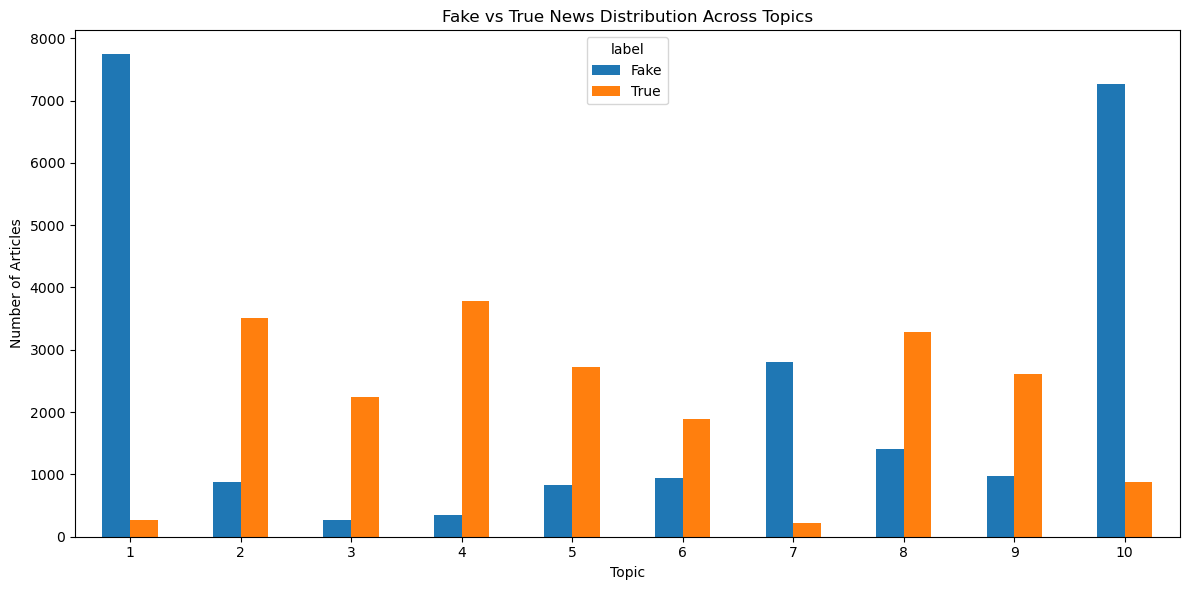

In [17]:
topic_label_distribution.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Topic")
plt.ylabel("Number of Articles")
plt.title("Fake vs True News Distribution Across Topics")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [18]:
os.makedirs("../models", exist_ok=True)

with open("../models/lda_topic_model.pkl", "wb") as f:
    pickle.dump(lda_model, f)

with open("../models/topic_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("Topic model and vectorizer saved successfully.")

Topic model and vectorizer saved successfully.


In [19]:
os.makedirs("../data/processed", exist_ok=True)

news_df.to_csv(
    "../data/processed/news_with_topics.csv",
    index=False
)

print("Topic-labelled dataset saved successfully.")

Topic-labelled dataset saved successfully.
